In [18]:
import pandas as pd 
import numpy as np

df_vendas = pd.read_csv('vendas_tech.csv',encoding='utf-8', sep=',', low_memory=False)
display(df_vendas)

df_gerentes = pd.read_excel('gerentes_lojas.xlsx')
display(df_gerentes)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


In [19]:
#Inspeção

display(df_vendas)
# display(df_vendas.head(15))   # Exibe as (x) primeiras linhas 
# display(df_vendas.tail(15))   # Exibe as (x) últimas linhas 
# display(df_vendas.sample(15)) # Exibe (x) linhas aleatórias
# display(df_vendas.shape)      # Exibe a quantidade de linhas e colunas (Série)
# display(df_vendas.columns)    # Exibe uma lista com o cabeçalho


# Funções iniciais comuns em projetos de dados
display(df_vendas.info())     # Exibe informações da base (Quais são as colunas (Séries), quantas informações tem na base, para cada coluna exibe quantos não nulos e o tipo de dado)
display(df_vendas.describe()) # Descrição estatística da base

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            98099 non-null   str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
 7   Data_Base       1 non-null       str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.1 MB


None

,ID_Pedido,Preco_Unitario,Qtd
count,100100.000000,100100.000000,100100.000000
mean,50004.810180,2000.204595,1.499101
std,28866.872543,1841.050733,1.241605
min,1.000000,40.000000,1.000000
25%,25008.750000,120.000000,1.000000
50%,50004.500000,1200.000000,1.000000
75%,75002.250000,3200.000000,1.000000
max,100000.000000,5500.000000,10.000000


In [20]:
# Tratamento de dados

# display(df_vendas['Loja'])                                # Selecionar série 
# display(df_vendas[['Loja', 'Cliente']])                   # Selecionar série | Inclusive, é assim que criamos um novo df como fatiamento de um atual, selecionamos as séries que queremos e salvamos em uma variável

# séries
df_analise = df_vendas.drop(columns=['Data_Base'])          # Excluir séries

# nulos (NaN)
# df_analise = df_analise.dropna()                          # Excluir todas as linhas que tem pelo menos um valor vazio
df_analise['Loja'] = df_analise['Loja'].fillna('Online')    # Preencher os valores vazios da série Loja como 'Online'

# tipos de dados
df_analise['Data'] = pd.to_datetime(df_analise['Data'], format='%Y-%m-%d')     # Converter tipo de dados

# padronização
df_analise['Loja'] = df_analise['Loja'].str.strip()
df_analise['Loja'] = df_analise['Loja'].str.title()

df_gerentes['Loja'] = df_gerentes['Loja'].str.strip()
df_gerentes['Loja'] = df_gerentes['Loja'].str.title()

# encadeamento
# df_analise['Loja'] = df_analise['Loja'].fillna('Online').str.strip().str.title()

# dupicatas
df_analise = df_analise.drop_duplicates(subset=['ID_Pedido'], keep='first')     # Excluir duplicadas | Subset é a série chave | keep é pra definir qual será mantido

display(df_analise)
display(df_analise.info())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB


None

In [21]:
# Criar novas colunas

# faturamento
df_analise['Faturamento']       = df_analise['Qtd'] * df_analise['Preco_Unitario']

# forma de venda
df_analise['Forma_de_Venda']    = np.where(df_analise['Loja'] == 'Online', 'Online', 'Presencial') # nova coluna | where(condição, valor se verdadeiro, valor se falso)

# região
display(df_analise['Loja'].unique()) # Exibe lista com valores únicos para a série definida
    # a estrutura para funções é sempre             df_example['Série].função()
        # calcular a média de uma série numérica:   df_example['Série].mean()
        # calcular a soma de uma série numérica:    df_example['Série].sum()
        # quantas vezes aparece cada valor:         df_example['Série].value_counts()

dict_regiões            = {
    'São Paulo'         : 'Sudeste',
    'Belo Horizonte'    : 'Sudeste',
    'Online'            : 'Online', 
    'Rio De Janeiro'    : 'Sudeste',
    'Salvador'          : 'Nordeste',
    'Recife'            : 'Nordeste',
    'Curitiba'          : 'Sul',
    'Porto Alegre'      : 'Sul'
}
df_analise['Região']    = df_analise['Loja'].map(dict_regiões) # Mapear os valores de uma nova série, pode ser através de um dicionário ou função (a função recebe o valor da série definida)


display(df_analise)
display(df_analise.isna().sum()) # Trazer a qtd de valores nulos por série

<StringArray>
[     'São Paulo', 'Belo Horizonte',         'Online', 'Rio De Janeiro',
       'Salvador',         'Recife',       'Curitiba',   'Porto Alegre']
Length: 8, dtype: str

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Região
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_de_Venda    0
Região            0
dtype: int64

In [22]:
# Analisar -> Filtrar

# ordenação de valores
df_analise = df_analise.sort_values(by=['Data', 'Faturamento'], ascending=True)  # Ordenar valores do df
df_analise = df_analise.reset_index(drop=True)  # Resetar o índice numérico | drop = True - descartar o índice antigo / False - índice antigo como uma nova série

# .loc - de acordo com o nome da série e o índice
id_pedido = 4

loja    = df_analise.loc[df_analise['ID_Pedido'] == id_pedido, 'Loja'].values[0]
produto = df_analise.loc[df_analise['ID_Pedido'] == id_pedido, 'Produto'].values[0]
cliente = df_analise.loc[df_analise['ID_Pedido'] == id_pedido, 'Cliente'].values[0]

print(loja, produto, cliente)

# .iloc - por posição (x, y) fixa
loja    = df_analise.iloc[id_pedido-1, 2]
produto = df_analise.iloc[id_pedido-1, 3]
cliente = df_analise.iloc[id_pedido-1, 6]

print(loja, produto, cliente)

# condicional
df_id_pedido = df_analise[df_analise['ID_Pedido'] == 4]
display(df_id_pedido)

# Exportar pedaços da base
df_vendas_sp = df_analise[df_analise['Loja'] == 'São Paulo']
df_vendas_sp.to_csv('Vendas_SP.csv', index=False)

# exportar vendas de 2024
df_vendas_2024 = df_analise[df_analise['Data'].dt.year == 2024] 

# duplas condições
df_vendas_HDMI_Sul = df_analise[(df_analise['Produto'] == 'Cabo HDMI') & (df_analise['Região'] == 'Sul')] # & = e, | = ou

display(df_vendas_HDMI_Sul)

Rio De Janeiro Mouse Gamer Cliente_17343
Porto Alegre Cabo HDMI Cliente_22886


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Região
94164,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Região
0,1700,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_14435,40.0,Presencial,Sul
2,35599,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_18680,40.0,Presencial,Sul
3,37130,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_22886,40.0,Presencial,Sul
4,49140,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_24445,40.0,Presencial,Sul
9,70138,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_9348,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99874,75695,2024-12-30,Porto Alegre,Cabo HDMI,40.0,1,Cliente_29587,40.0,Presencial,Sul
99875,78584,2024-12-30,Curitiba,Cabo HDMI,40.0,1,Cliente_21307,40.0,Presencial,Sul
99880,35127,2024-12-30,Curitiba,Cabo HDMI,40.0,2,Cliente_20687,80.0,Presencial,Sul
99881,47774,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_14363,80.0,Presencial,Sul


In [23]:
# Analisar -> Agrupamento

# ranking de faturamento por loja | groupby
analise_lojas = df_analise[['Loja', 'Faturamento']].groupby('Loja').sum().sort_values(by='Faturamento', ascending=False).reset_index()
analise_lojas['Faturamento Formatado'] = analise_lojas['Faturamento'].map('R${:,.2f}'.format)

display(analise_lojas)

# ranking de produtos que mais venderam no online
df_vendas_online        = df_analise[df_analise['Região'] == 'Online']
analise_produtos_online = df_vendas_online[['Produto', 'Qtd']].groupby('Produto').sum().sort_values(by='Qtd', ascending=False)
analise_produtos_online = analise_produtos_online.rename(columns={'Qtd': 'Vendas Totais'})

display(analise_produtos_online)

# analise de ranking por loja e por produto
    # quais produtos venderam mais em cada uma das lojas
analise_produtos_em_lojas = df_analise[['Loja', 'Produto', 'Qtd']].groupby(['Loja', 'Produto']).sum()

with pd.option_context('display.max_rows', None):
    display(analise_produtos_em_lojas)
    
    #quais lojas mais venderam os produtos
analise_lojas_em_produtos = df_analise[['Loja', 'Produto', 'Qtd']].groupby(['Produto', 'Loja']).sum()

display(analise_lojas_em_produtos)

,Loja,Faturamento,Faturamento Formatado
0,Salvador,42300610.0,"R$42,300,610.00"
1,Rio De Janeiro,42294720.0,"R$42,294,720.00"
2,Recife,42190390.0,"R$42,190,390.00"
3,São Paulo,42090690.0,"R$42,090,690.00"
4,Belo Horizonte,41714890.0,"R$41,714,890.00"
5,Porto Alegre,41678460.0,"R$41,678,460.00"
6,Curitiba,41121720.0,"R$41,121,720.00"
7,Online,6080850.0,"R$6,080,850.00"


,Vendas Totais
Produto,
Notebook HP,442
Cabo HDMI,403
iPhone 14,390
Mouse Gamer,379
Notebook Dell,369
Teclado Mecânico,343
"Monitor 27""",332
Smartphone Samsung,311


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
               Smartphone Samsung  2597
               Teclado Mecânico    2609
               iPhone 14           2478
Curitiba       Cabo HDMI           2698
               Monitor 27"         2626
               Mouse Gamer         2600
               Notebook Dell       2517
               Notebook HP         2529
               Smartphone Samsung  2444
               Teclado Mecânico    2742
               iPhone 14           2652
Online         Cabo HDMI            403
               Monitor 27"          332
               Mouse Gamer          379
               Notebook Dell        369
               Notebook HP          442
               Smartphone Samsung   311
               Teclado Mecânico     343
               iPhone 14            390
Porto Alegre   Cabo HDMI           2571
               Monitor 27"         2655
               Mouse Gamer         2611
               Notebook Dell       2770
               Notebook HP         2511
               Smartphone Samsung  2603
               Teclado Mecânico    2598
               iPhone 14           2540
Recife         Cabo HDMI           2534
               Monitor 27"         2647
               Mouse Gamer         2639
               Notebook Dell       2566
               Notebook HP         2651
               Smartphone Samsung  2660
               Teclado Mecânico    2775
               iPhone 14           2652
Rio De Janeiro Cabo HDMI           2747
               Monitor 27"         2798
               Mouse Gamer         2652
               Notebook Dell       2534
               Notebook HP         2614
               Smartphone Samsung  2626
               Teclado Mecânico    2548
               iPhone 14           2702
Salvador       Cabo HDMI           2566
               Monitor 27"         2545
               Mouse Gamer         2711
               Notebook Dell       2512
               Notebook HP         2785
               Smartphone Samsung  2627
               Teclado Mecânico    2579
               iPhone 14           2671
São Paulo      Cabo HDMI           2649
               Monitor 27"         2796
               Mouse Gamer         2714
               Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

Qtd
Produto   Loja                
Cabo HDMI Belo Horizonte  2636
          Curitiba        2698
          Online           403
          Porto Alegre    2571
          Recife          2534
...                        ...
iPhone 14 Porto Alegre    2540
          Recife          2652
          Rio De Janeiro  2702
          Salvador        2671
          São Paulo       2735

[64 rows x 1 columns]

In [24]:
# quais gerentes bateram a meta em jan/2023
df_meta = df_analise[(df_analise['Data'].dt.year == 2023) & (df_analise['Data'].dt.month == 1)]

df_meta = df_meta[['Loja', 'Faturamento']].groupby('Loja', as_index=False).sum()

df_meta = df_meta.merge(df_gerentes, on='Loja', how='left') 
    # 'on' - definir a coluna que vai fazer a correspondência entre df, quando a coluna tem o mesmo nome em ambos df
    # how - tipo de join (sql) 
    # df_meta.merge(df_gerentes, left_on='Loja', right_on='Cidade') # definir a coluna que vai fazer a correspondência entre df, quando a coluna nome diferente nos df

# df_meta = pd.concat([a, b])  #concat - juntar duas tabelas com mesmo cabeçalho

df_meta['Bateu Meta'] = np.where(df_meta['Faturamento'] >= df_meta['Meta_Mensal'], 'Sim', 'Não')

display(df_meta)

,Loja,Faturamento,Gerente,Meta_Mensal,Bateu Meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
1,Curitiba,1986920.0,Roberto,45000.0,Sim
2,Online,404570.0,NaN,NaN,Não
3,Porto Alegre,1726640.0,Pedro,42000.0,Sim
4,Recife,1779020.0,Marcos,48000.0,Sim
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,São Paulo,1831140.0,Carlos,50000.0,Sim


,Faturamento
Mês-Ano,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


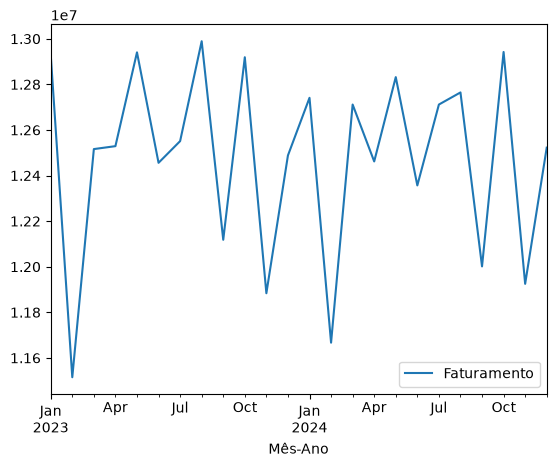

In [ ]:
# Análise de série temporal

df_analise['Mês-Ano'] = df_analise['Data'].dt.to_period('M')
df_vendas_mes = df_analise[['Mês-Ano', 'Faturamento']].groupby('Mês-Ano').sum()
df_vendas_mes.plot()

display(df_vendas_mes)